(backward_compatibility)=
# Backward Compatibility

The legacy MOLASS program produces its analysis results in Excel books. We will explain here how to do the same in Molass Library. 

## Learning Points
* rgcurve = ssd.xr.compute_rgcurve()
* ranges = decomposition.get_paired_ranges()
* decomposition.plot_components(rgcurve=rgcurve, ranges=ranges)
* rgcurve_atsas = ssd.xr.compute_rgcurve_atsas()
* mapping = ssd.estimate_mapping()
* conc_info = ssd.make_conc_info(mapping)
* rg_info = rgcurve, rgcurve_atsas
* make_v1report(ssd, conc_info=conc_info, rg_info=rg_info, lr_info=decomposition, ranges=ranges)

## Preparation for the Report

Although it is possible to do it as well without any preparation (that is, implicitly all by default), we will show explicitly what to prepare in the hope that it will better serve as explanation and can be easy to modify.

First, we will prepare rg curves and analysis ranges. 

developer memo: remember that "LowRank.CoupledAdjuster.select_components" is not implemented yet.


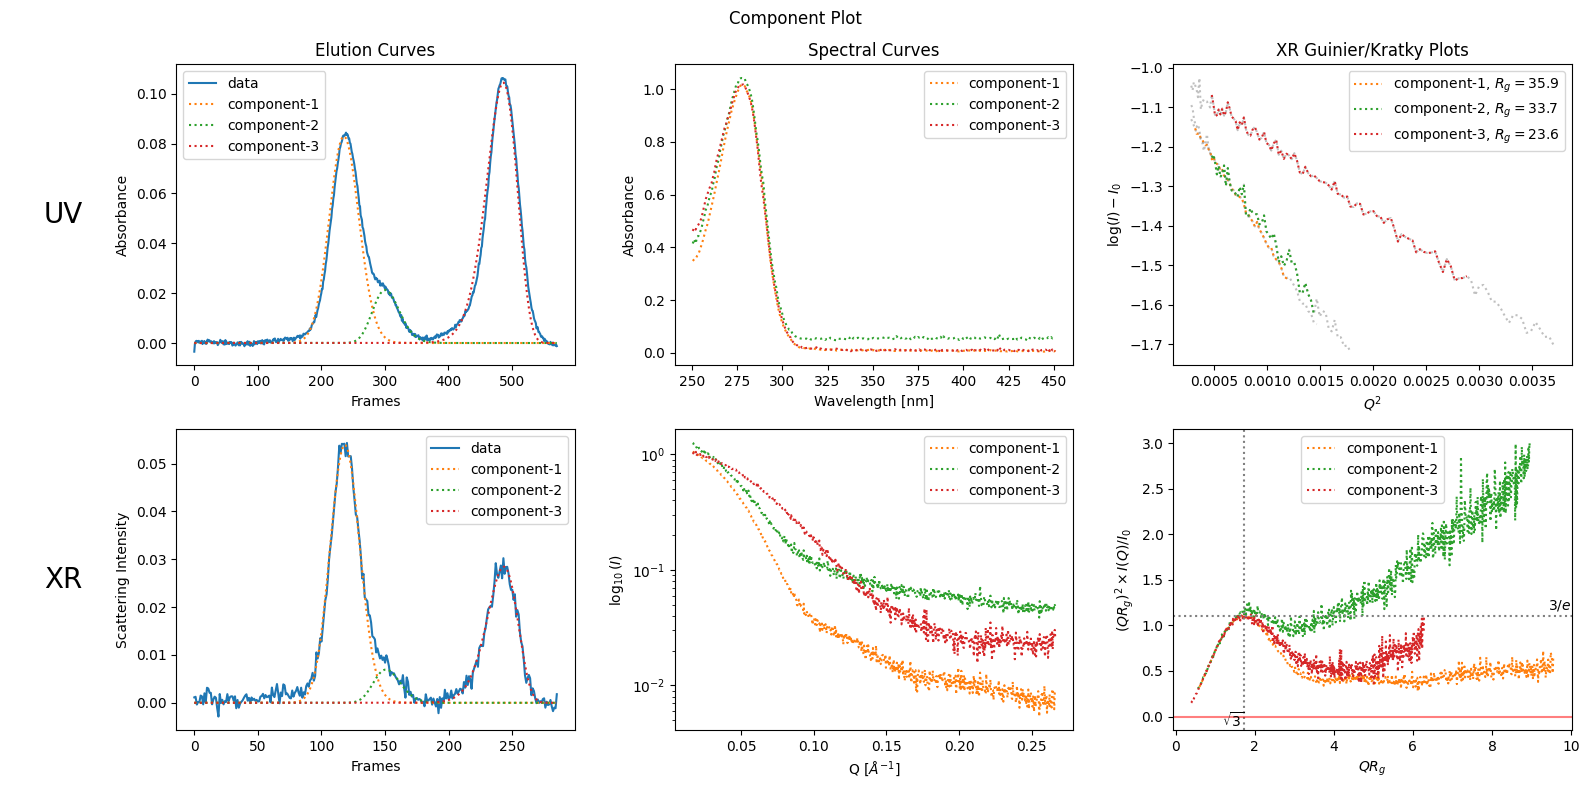

In [1]:
from molass import get_version
assert get_version() >= '0.1.0', "This script requires molass version 0.1.0 or higher."
from molass_data import SAMPLE1
from molass.DataObjects import SecSaxsData as SSD
ssd = SSD(SAMPLE1)
trimmed_ssd = ssd.trimmed_copy()
corrected_ssd = trimmed_ssd.corrected_copy()
decomposition = corrected_ssd.quick_decomposition(num_components=3)
plot5 = decomposition.plot_components()

100%|██████████| 286/286 [01:03<00:00,  4.51it/s]


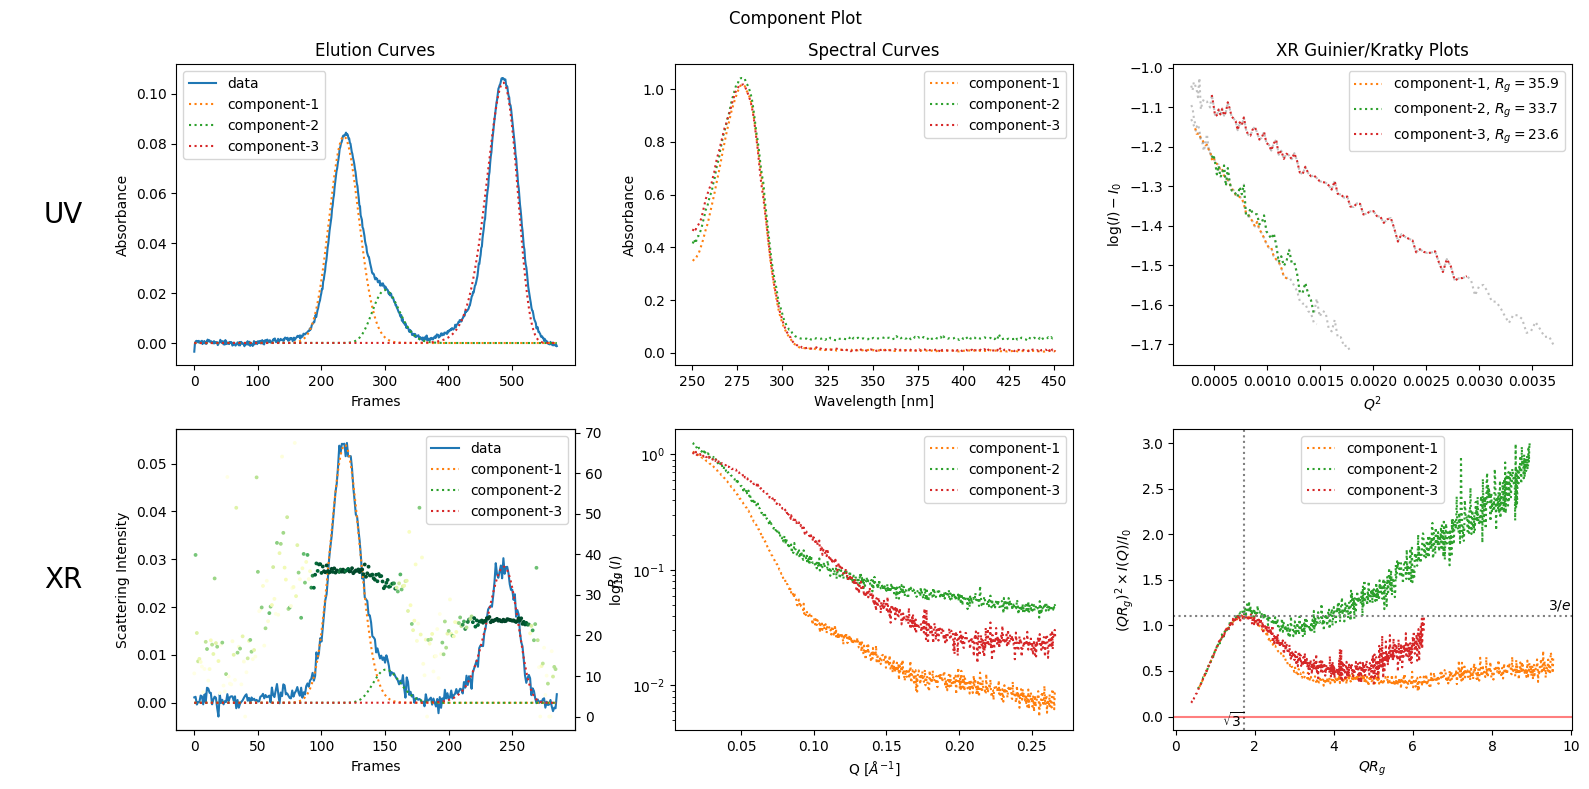

In [2]:
rgcurve = corrected_ssd.xr.compute_rgcurve()
plot6 = decomposition.plot_components(rgcurve=rgcurve)

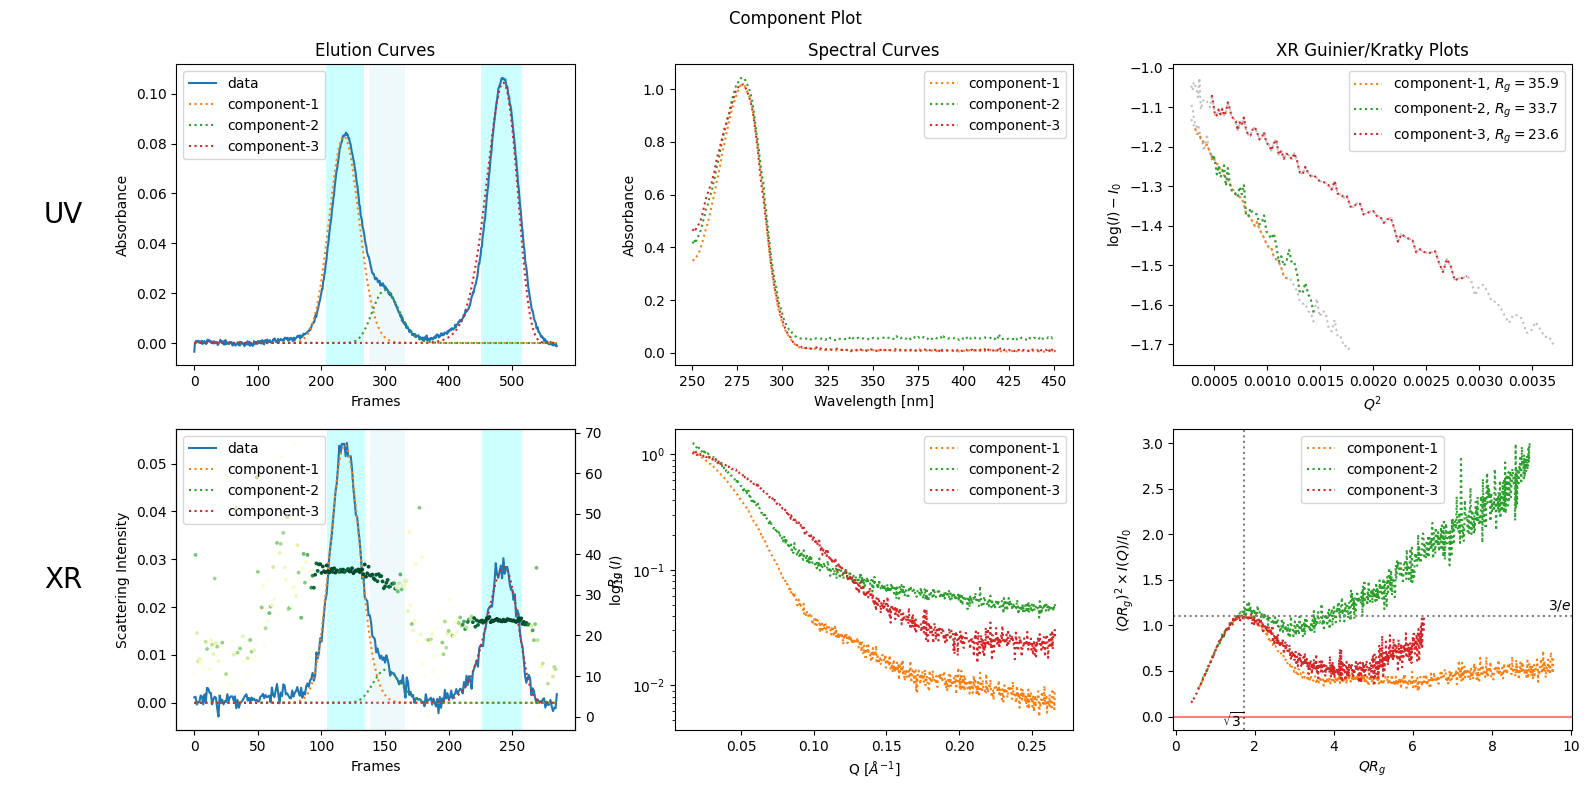

In [3]:
ranges = decomposition.get_paired_ranges()
plot8 = decomposition.plot_components(rgcurve=rgcurve, ranges=ranges)

In [4]:
rgcurve_atsas = corrected_ssd.xr.compute_rgcurve_atsas()

100%|██████████| 286/286 [01:17<00:00,  3.69it/s]


## Making the Excel Report

To make the erport, we also need the concentration information which can be prepared as follows.

In [5]:
import molass.Reports.ReportUtils
from importlib import reload
reload(molass.Reports.ReportUtils)
from molass.Reports.ReportUtils import make_v1report

mapping = corrected_ssd.estimate_mapping()
conc_info = corrected_ssd.make_conc_info(mapping)
rg_info = rgcurve, rgcurve_atsas
make_v1report(corrected_ssd, conc_info=conc_info, rg_info=rg_info, lr_info=decomposition, ranges=ranges, debug=True)

  0%|          | 0/10 [00:00<?, ?it/s]developer memo: remember that "LowRank.CoupledAdjuster.select_components" is not implemented yet.


make_v1report_impl: ranges= [(104, 118), (118, 134), (138, 166), (226, 243), (243, 258)]


([8], (1, 9, False)):  90%|█████████ | 9/10 [00:29<00:03,  3.33s/it]
excessive step_done call!


Saving Guinier Analysis Report to d:\Github\molass-tutorial\chapters\08\book1.xlsx
add_guinier_annonations: sheet_path= d:\Github\molass-tutorial\chapters\08\book1.xlsx(Guinier Analysis)
add_guinier_annonations: ranges= [(104, 118), (118, 134), (138, 166), (226, 243), (243, 258)]


Killed the remaining process pid=30248
